# 1. Import Libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

c:\Users\HP-PC\anaconda3\envs\myenv\Lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


# 2. Load Test Data

In [3]:
processed_path = "../data/processed"

X_test = np.load(f"{processed_path}/X_test.npy")
y_test = np.load(f"{processed_path}/y_test.npy")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (8936, 300)
y_test shape: (8936,)


# 3. Load Trained Model

In [4]:
model = load_model("../models/lstm_v2.keras")

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 300, 128)       │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,075,141 (30.80 MB)

 Trainable params: 2,691,713 (10.27 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,383,428 (20.54 MB)

# 4. Prediction

In [5]:
# Model outputs probability

y_pred_prob = model.predict(X_test)
print(y_pred_prob[:5])

# Convert probability to class
y_pred = (
    y_pred_prob >= 0.5
).astype(int)

y_pred = y_pred.flatten()

print(y_pred[:10])

280/280 ━━━━━━━━━━━━━━━━━━━━ 14s 49ms/step
[[9.9650472e-01]
 [9.9508047e-01]
 [9.9738628e-01]
 [1.7353801e-04]
 [9.9913394e-01]]
[1 1 1 0 1 1 1 0 0 1]


# 5. Evaluation

## Classification Metrics

In [6]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9936213070725156
Precision: 0.9903913756737754
Recall   : 0.9962281942479962
F1 Score : 0.993301210483018


## Classification Report

In [7]:
print(classification_report(y_test, y_pred, target_names=["Fake News", "Real News"]))

              precision    recall  f1-score   support

   Fake News       1.00      0.99      0.99      4694
   Real News       0.99      1.00      0.99      4242

    accuracy                           0.99      8936
   macro avg       0.99      0.99      0.99      8936
weighted avg       0.99      0.99      0.99      8936



## Confusion Matrix

[[4653   41]
 [  16 4226]]


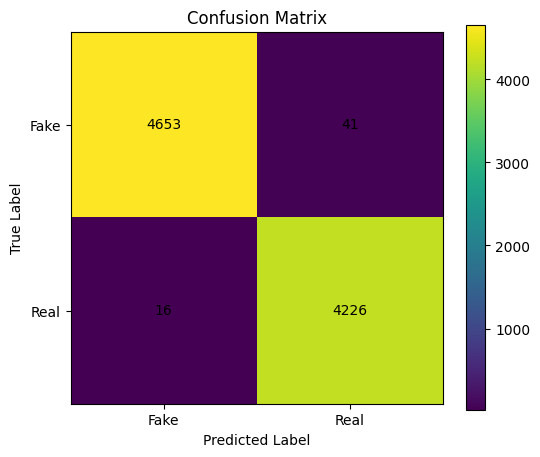

In [8]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.xticks([0,1], ["Fake","Real"])
plt.yticks([0,1], ["Fake","Real"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j], ha="center", va="center")
plt.show()

## ROC-AUC

ROC-AUC: 0.9976228342902462


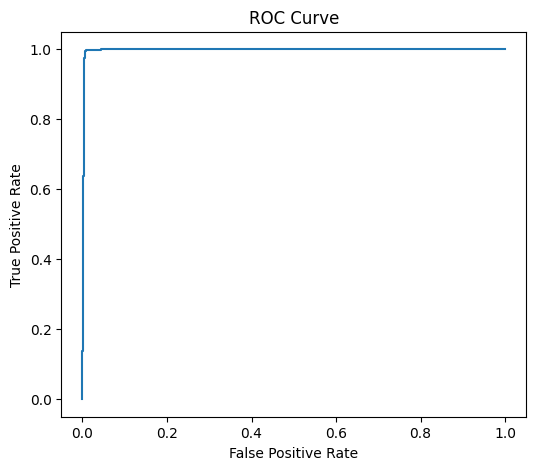

In [11]:
roc_auc = roc_auc_score(y_test, y_pred_prob)

print("ROC-AUC:", roc_auc)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

# 6. Save Evaluation Metrics

In [10]:
os.makedirs(
    "../outputs/metrics",
    exist_ok=True
)

metrics = {
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1_score": f1,
    "roc_auc": roc_auc
}

import json
with open(
    "../outputs/metrics/lstm_metrics.json",
    "w"
) as file:
    json.dump(
        metrics,
        file,
        indent=4
    )

print("Metrics saved successfully")

Metrics saved successfully
